# 10 - WEO Excel Machine Learning Prediction Lab

This lab builds a practical predictive model from the WEO Excel workbook.

Use case: **predict next-year real GDP growth** from current-year macroeconomic indicators such as inflation, unemployment, debt, current account balance, savings, investment, trade growth, and GDP per capita.

## Important: Use a Python Notebook Runtime

Run this notebook with a **Python 3** kernel in Jupyter, VS Code, JupyterLab, or Google Colab. Do not run these cells in SQL Server query mode.

This notebook uses the WEO Excel workbook from Module 4. Locally, it looks for `Module 4/labs/python-data-manipulation-database-connectivity/data/WEOApr2026all.xlsx`. In Google Colab, it also checks `/content/WEOApr2026all.xlsx` and can prompt you to upload the file if needed.

## 0. Install Packages

In [29]:
%pip install pandas numpy scipy matplotlib seaborn scikit-learn openpyxl joblib -q

Note: you may need to restart the kernel to use updated packages.


## 1. Imports

In [30]:
from pathlib import Path
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump, load
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## 2. Display, Output, and Chart Style Settings

The pandas settings only change how tables are displayed. They do not clean or transform the data.

In [31]:
# These settings only control how pandas tables are displayed in the notebook.
# They do not change the data.
pd.set_option("display.max_columns", 60)  # Show up to 60 columns before pandas hides columns with "...".
pd.set_option("display.width", 160)       # Make printed tables wider so rows wrap less often.

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid") if "sns" in globals() else None

## 3. Locate and Open the WEO Workbook

In [47]:
def find_weo_workbook():
    """Find the WEO workbook locally, in Colab, or through a Colab upload prompt."""
    candidate_paths = [
        Path("../../../Module 4/labs/python-data-manipulation-database-connectivity/data/WEOApr2026all.xlsx"),
        Path("Module 4/labs/python-data-manipulation-database-connectivity/data/WEOApr2026all.xlsx"),
        Path("data/WEOApr2026all.xlsx"),
        Path("/content/WEOApr2026all.xlsx"),
        Path("WEOApr2026all.xlsx"),
    ]

    for path in candidate_paths:
        if path.exists():
            return path

    # This block only runs in Google Colab. It lets a learner upload the Excel file manually.
    try:
        from google.colab import files
        print("Upload WEOApr2026all.xlsx from Module 4 to continue.")
        uploaded = files.upload()
        if "WEOApr2026all.xlsx" in uploaded:
            return Path("WEOApr2026all.xlsx")
    except Exception:
        pass

    raise FileNotFoundError(
        "WEOApr2026all.xlsx was not found. Run locally from the repo, or upload the Excel file in Google Colab."
    )

In [33]:
WEO_PATH = find_weo_workbook()
print("Using workbook:", WEO_PATH)

excel_file = pd.ExcelFile(WEO_PATH)
print("Workbook sheets:", excel_file.sheet_names)

Using workbook: ../../../Module 4/labs/python-data-manipulation-database-connectivity/data/WEOApr2026all.xlsx


Workbook sheets: ['April 2026 WEO', 'Countries', 'Country Groups', 'Commodity Prices', 'Country Group Composition']


## 4. Indicator Mapping and Helper Functions

The raw workbook mixes uppercase names, dotted names, and compact names. The helper functions standardize everything into readable `snake_case` names before modeling.

In [34]:
# We use short, consistent snake_case names in our analysis DataFrames.
# The original WEO indicator IDs are kept only while extracting the data.
INDICATOR_LABELS = {
    "NGDP_RPCH": "gdp_growth_pct",
    "PCPIPCH": "inflation_pct",
    "LUR": "unemployment_rate",
    "BCA_NGDPD": "current_account_pct_gdp",
    "GGXWDG_NGDP": "government_debt_pct_gdp",
    "NGDPDPC": "gdp_per_capita_usd",
    "NID_NGDP": "investment_pct_gdp",
    "NGSD_NGDP": "savings_pct_gdp",
    "TX_RPCH": "export_volume_growth_pct",
    "TM_RPCH": "import_volume_growth_pct",
}

In [48]:
def standardize_column_names(frame):
    """Convert non-year column names to snake_case for consistent analysis code."""
    renamed_columns = {}

    for column in frame.columns:
        # WEO year columns arrive as integers such as 1980, 2026, and 2031.
        # Keep them as integers because they are easier to identify and melt later.
        if isinstance(column, int):
            renamed_columns[column] = column
            continue

        clean_name = (
            str(column)
            .strip()
            .lower()
            .replace(".", "_")
            .replace(" ", "_")
            .replace("-", "_")
        )
        renamed_columns[column] = clean_name

    return frame.rename(columns=renamed_columns)


def get_year_columns(frame):
    """Return columns that represent years, for example 1980, 2024, or 2031."""
    return [column for column in frame.columns if isinstance(column, int) or str(column).isdigit()]


def load_weo_sheets(path):
    """Load and standardize the useful WEO workbook sheets."""
    countries = standardize_column_names(pd.read_excel(path, sheet_name="Countries"))
    country_groups = standardize_column_names(pd.read_excel(path, sheet_name="Country Groups"))
    commodity_prices = standardize_column_names(pd.read_excel(path, sheet_name="Commodity Prices"))
    group_composition = standardize_column_names(pd.read_excel(path, sheet_name="Country Group Composition"))

    # This sheet uses compact column names like groupname and countrycode.
    # Rename them once so the rest of the notebook can use readable snake_case names.
    group_composition = group_composition.rename(columns={
        "groupcode": "group_code",
        "groupname": "group_name",
        "groupcode_previous": "group_code_previous",
        "countrycode": "country_id",
        "countryname": "country_name",
        "countrycode_previous": "country_code_previous",
    })

    return countries, country_groups, commodity_prices, group_composition


def make_long_indicator_data(frame, indicator_ids, source_sheet):
    """Convert WEO wide year columns into a tidy row-per-country-year format."""
    year_columns = get_year_columns(frame)
    id_columns = ["country_id", "country", "indicator_id", "indicator", "unit"]

    filtered = frame.loc[frame["indicator_id"].isin(indicator_ids), id_columns + year_columns].copy()

    long_df = filtered.melt(
        id_vars=id_columns,
        value_vars=year_columns,
        var_name="year",
        value_name="value",
    )
    long_df["year"] = long_df["year"].astype(int)
    long_df["value"] = pd.to_numeric(long_df["value"], errors="coerce")
    long_df["source_sheet"] = source_sheet
    return long_df


def make_country_macro_dataframe(countries, group_composition):
    """Create one country-year row with selected WEO indicators as columns."""
    country_long = make_long_indicator_data(countries, list(INDICATOR_LABELS), "Countries")

    country_macro = (
        country_long.pivot_table(
            index=["country_id", "country", "year"],
            columns="indicator_id",
            values="value",
            aggfunc="first",
        )
        .reset_index()
        .rename(columns=INDICATOR_LABELS)
    )

    # Remove the pivot column-axis name so displays do not show an old label above the header row.
    country_macro.columns.name = None

    advanced_codes = set(group_composition.loc[group_composition["group_name"].eq("Advanced Economies"), "country_id"])
    emerging_codes = set(group_composition.loc[group_composition["group_name"].eq("Emerging Market and Developing Economies"), "country_id"])
    ssa_codes = set(group_composition.loc[group_composition["group_name"].eq("Sub-Saharan Africa (SSA)"), "country_id"])

    country_macro["economic_group"] = np.select(
        [country_macro["country_id"].isin(advanced_codes), country_macro["country_id"].isin(emerging_codes)],
        ["Advanced Economies", "Emerging Market and Developing Economies"],
        default="Other",
    )
    country_macro["is_sub_saharan_africa"] = country_macro["country_id"].isin(ssa_codes)

    return country_macro, country_long

## 5. Build the Country-Year DataFrame

Each row in `country_macro` represents one country in one year. Each selected WEO indicator becomes a feature column.

In [36]:
countries_raw, country_groups_raw, commodity_prices_raw, group_composition = load_weo_sheets(WEO_PATH)
country_macro, country_long = make_country_macro_dataframe(countries_raw, group_composition)

print("Countries sheet rows:", len(countries_raw))
print("Country-year analytical rows:", len(country_macro))
display(country_macro.head())

Countries sheet rows: 8668
Country-year analytical rows: 9398


,country_id,country,year,current_account_pct_gdp,government_debt_pct_gdp,unemployment_rate,gdp_per_capita_usd,gdp_growth_pct,savings_pct_gdp,investment_pct_gdp,inflation_pct,import_volume_growth_pct,export_volume_growth_pct,economic_group,is_sub_saharan_africa
0,ABW,"Aruba, Kingdom of the Netherlands",1986,NaN,NaN,19.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Emerging Market and Developing Economies,False
1,ABW,"Aruba, Kingdom of the Netherlands",1987,NaN,NaN,14.5,NaN,16.079,NaN,NaN,3.639,NaN,NaN,Emerging Market and Developing Economies,False
2,ABW,"Aruba, Kingdom of the Netherlands",1988,NaN,NaN,5.0,NaN,18.640,NaN,NaN,3.121,NaN,NaN,Emerging Market and Developing Economies,False
3,ABW,"Aruba, Kingdom of the Netherlands",1989,NaN,NaN,1.5,NaN,12.095,NaN,NaN,3.989,NaN,NaN,Emerging Market and Developing Economies,False
4,ABW,"Aruba, Kingdom of the Netherlands",1990,NaN,NaN,1.3,NaN,3.977,NaN,NaN,5.838,NaN,NaN,Emerging Market and Developing Economies,False


## 6. Create the Prediction Target

Supervised learning needs:

- **features (`X`)**: input columns used to make the prediction,
- **target (`y`)**: the value we want to predict.

Here, the target is next year's GDP growth for the same country. We create it with `groupby("country_id").shift(-1)`.

In [37]:
model_df = country_macro.sort_values(["country_id", "year"]).copy()

# For each country, move next year's GDP growth up into the current row.
model_df["next_year_gdp_growth_pct"] = model_df.groupby("country_id")["gdp_growth_pct"].shift(-1)

feature_columns = [
    "gdp_growth_pct",
    "inflation_pct",
    "unemployment_rate",
    "government_debt_pct_gdp",
    "current_account_pct_gdp",
    "investment_pct_gdp",
    "savings_pct_gdp",
    "export_volume_growth_pct",
    "import_volume_growth_pct",
    "gdp_per_capita_usd",
]
target_column = "next_year_gdp_growth_pct"

# Use recent decades with stronger coverage. Drop rows only when the target is missing.
ml_df = model_df[model_df["year"].between(2010, 2030)].dropna(subset=[target_column]).copy()

print("ML rows:", len(ml_df))
print("Countries:", ml_df["country"].nunique())
display(ml_df[["country", "year"] + feature_columns + [target_column]].head())

ML rows: 4061
Countries: 196


,country,year,gdp_growth_pct,inflation_pct,unemployment_rate,government_debt_pct_gdp,current_account_pct_gdp,investment_pct_gdp,savings_pct_gdp,export_volume_growth_pct,import_volume_growth_pct,gdp_per_capita_usd,next_year_gdp_growth_pct
24,"Aruba, Kingdom of the Netherlands",2010,-3.307,2.078,10.6,54.662,-18.737,NaN,13.255,NaN,NaN,22460.200,3.608
25,"Aruba, Kingdom of the Netherlands",2011,3.608,4.375,8.9,59.347,-10.020,NaN,12.481,NaN,NaN,24440.011,-1.155
26,"Aruba, Kingdom of the Netherlands",2012,-1.155,0.571,9.6,65.533,3.602,NaN,13.084,NaN,NaN,24334.537,7.071
27,"Aruba, Kingdom of the Netherlands",2013,7.071,-2.372,7.6,70.032,-11.957,NaN,15.247,NaN,NaN,25458.470,1.426
28,"Aruba, Kingdom of the Netherlands",2014,1.426,0.423,7.5,77.709,-4.797,NaN,17.530,NaN,NaN,25945.459,3.612


### Interpreting the Modeling Dataset

The current workbook creates about **4,061 modeling rows** across **196 countries**. Missing feature values are expected because not every WEO indicator is available for every country and year. We handle that with imputation in the model pipeline.

## 7. Critical ML Concepts Before Training

**Imputation** fills missing feature values. In this notebook, `SimpleImputer(strategy="median")` replaces missing numeric values with the training-set median.

**StandardScaler** standardizes numeric features by subtracting the mean and dividing by the standard deviation. This helps models such as linear regression when features are on different scales, for example inflation percentages versus GDP per capita in dollars.

**One-hot encoding** converts text categories into numeric columns. We are not using categorical features in this model, but if we included `economic_group`, we would use `OneHotEncoder`. A typical pattern is:

```python
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocess = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_columns),
    ("category", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
])
```

We keep this first model numeric-only so the pipeline is easier to follow.

## 8. Train/Test Split

For time-oriented economic data, train on earlier years and test on later years. This better simulates real forecasting than randomly mixing all years.

In [38]:
train_df = ml_df[ml_df["year"] <= 2023].copy()
test_df = ml_df[ml_df["year"] >= 2024].copy()

X_train = train_df[feature_columns]
y_train = train_df[target_column]
X_test = test_df[feature_columns]
y_test = test_df[target_column]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Test years:", sorted(test_df["year"].unique()))

Training rows: 2732
Testing rows: 1329
Test years: [np.int64(2024), np.int64(2025), np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030)]


### Interpreting the Split

The current split gives about **2,732 training rows** and **1,329 testing rows**. The model learns from years up to 2023, then it is evaluated on 2024 to 2030 rows.

## 9. Evaluation Metrics

We use three regression metrics:

**MAE (Mean Absolute Error)**: average absolute prediction error. Range: `0` to infinity. Lower is better. Here it is measured in GDP-growth percentage points.

**RMSE (Root Mean Squared Error)**: similar to MAE, but it penalizes large mistakes more strongly. Range: `0` to infinity. Lower is better.

**R2 (R-squared)**: how much variation the model explains. Range: maximum is `1`. `1` is perfect, `0` is roughly no better than predicting the average, and negative values mean worse than that simple average baseline.

## 10. Baseline Model: Linear Regression

This pipeline first imputes missing values, then scales features, then trains a linear regression model.

In [39]:
linear_model = Pipeline(steps=[
    # Step 1: fill missing numeric feature values with the median from training data.
    ("imputer", SimpleImputer(strategy="median")),

    # Step 2: put features on a comparable scale.
    ("scaler", StandardScaler()),

    # Step 3: train a simple regression model.
    ("model", LinearRegression()),
])

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear regression MAE:", round(linear_mae, 3))
print("Linear regression RMSE:", round(linear_rmse, 3))
print("Linear regression R2:", round(linear_r2, 3))

Linear regression MAE: 1.383
Linear regression RMSE: 2.747
Linear regression R2: 0.032


### Interpreting the Linear Regression Results

The current output shows MAE around **1.383**. That means the model's average absolute error is about **1.38 GDP-growth percentage points**.

RMSE is about **2.747**, which is larger than MAE. That tells us some prediction errors are much larger than the average error.

R2 is about **0.032**, which is close to zero. This model is only slightly better than a simple average-growth baseline on the test period.

## 11. Second Model: Random Forest Regression

A random forest can capture non-linear relationships. It does not require scaling, but it still needs imputation because some WEO feature values are missing.

In [40]:
forest_model = Pipeline(steps=[
    # Fill missing feature values before fitting the tree-based model.
    ("imputer", SimpleImputer(strategy="median")),

    # A random forest averages many decision trees.
    ("model", RandomForestRegressor(n_estimators=250, random_state=42, min_samples_leaf=3)),
])

forest_model.fit(X_train, y_train)
forest_predictions = forest_model.predict(X_test)

forest_mae = mean_absolute_error(y_test, forest_predictions)
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_predictions))
forest_r2 = r2_score(y_test, forest_predictions)

print("Random forest MAE:", round(forest_mae, 3))
print("Random forest RMSE:", round(forest_rmse, 3))
print("Random forest R2:", round(forest_r2, 3))

Random forest MAE: 1.738
Random forest RMSE: 3.09
Random forest R2: -0.224


### Interpreting the Random Forest Results

The current output shows MAE around **1.738**, RMSE around **3.090**, and R2 around **-0.224**.

The negative R2 means this random forest performed worse than simply predicting the average test-set growth value. This is a useful lesson: a more complex model is not automatically better.

## 12. Compare Models and Select the Best One

We select the best model using the lowest MAE because MAE is easy to explain in percentage points.

,model,metric,value
0,linear_regression,mae,1.383
1,linear_regression,rmse,2.747
2,linear_regression,r2,0.032
3,random_forest,mae,1.738
4,random_forest,rmse,3.090
5,random_forest,r2,-0.224


Best model by MAE: linear_regression


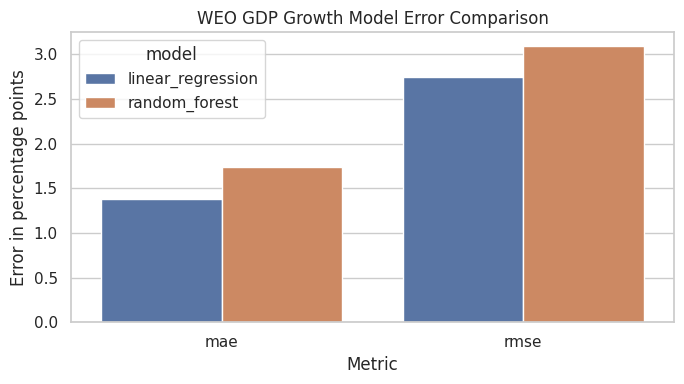

In [41]:
metrics = pd.DataFrame([
    {"model": "linear_regression", "metric": "mae", "value": linear_mae},
    {"model": "linear_regression", "metric": "rmse", "value": linear_rmse},
    {"model": "linear_regression", "metric": "r2", "value": linear_r2},
    {"model": "random_forest", "metric": "mae", "value": forest_mae},
    {"model": "random_forest", "metric": "rmse", "value": forest_rmse},
    {"model": "random_forest", "metric": "r2", "value": forest_r2},
]).round(3)

display(metrics)

best_model_name = "linear_regression" if linear_mae <= forest_mae else "random_forest"
best_model = linear_model if best_model_name == "linear_regression" else forest_model
print("Best model by MAE:", best_model_name)

plt.figure(figsize=(7, 4))
sns.barplot(data=metrics[metrics["metric"].isin(["mae", "rmse"])], x="metric", y="value", hue="model")
plt.title("WEO GDP Growth Model Error Comparison")
plt.xlabel("Metric")
plt.ylabel("Error in percentage points")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weo_ml_model_error_comparison.png", dpi=150)
plt.show()

### Interpreting the Model Comparison

With the current workbook, **linear regression** is the better model by MAE. It has lower MAE and RMSE than the random forest. The overall R2 remains weak, so this should be presented as a beginner modeling exercise, not as a production-grade forecast.

## 13. Review Actual vs Predicted Values

A prediction review table helps identify where the model made its largest mistakes.

,country,year,economic_group,next_year_gdp_growth_pct,linear_prediction,forest_prediction,forest_error
7719,"South Sudan, Republic of",2024,Emerging Market and Developing Economies,46.09,1.00,-4.03,-50.13
7827,Suriname,2028,Emerging Market and Developing Economies,43.46,3.94,5.80,-37.66
7826,Suriname,2027,Emerging Market and Developing Economies,28.54,3.55,-1.23,-29.77
7351,Sudan,2026,Emerging Market and Developing Economies,8.13,-1.91,-9.61,-17.74
7828,Suriname,2029,Emerging Market and Developing Economies,3.08,3.74,19.15,16.07
7349,Sudan,2024,Emerging Market and Developing Economies,3.22,-3.57,-11.49,-14.72
7720,"South Sudan, Republic of",2025,Emerging Market and Developing Economies,4.14,5.33,17.94,13.80
5279,"Macao Special Administrative Region, People's ...",2029,Advanced Economies,3.01,1.47,-10.65,-13.66
5278,"Macao Special Administrative Region, People's ...",2028,Advanced Economies,3.00,1.54,-10.65,-13.66
5277,"Macao Special Administrative Region, People's ...",2027,Advanced Economies,3.08,1.61,-10.56,-13.64


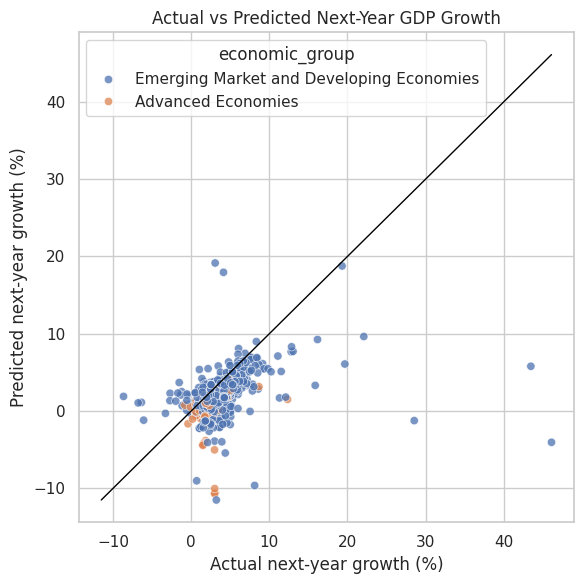

In [42]:
prediction_review = test_df[["country", "year", "economic_group", target_column]].copy()
prediction_review["linear_prediction"] = linear_predictions
prediction_review["forest_prediction"] = forest_predictions
prediction_review["forest_error"] = prediction_review["forest_prediction"] - prediction_review[target_column]

display(prediction_review.sort_values("forest_error", key=lambda s: s.abs(), ascending=False).head(15).round(2))

plt.figure(figsize=(6, 6))
sns.scatterplot(data=prediction_review, x=target_column, y="forest_prediction", hue="economic_group", alpha=0.75)
min_value = min(prediction_review[target_column].min(), prediction_review["forest_prediction"].min())
max_value = max(prediction_review[target_column].max(), prediction_review["forest_prediction"].max())
plt.plot([min_value, max_value], [min_value, max_value], color="black", linewidth=1)
plt.title("Actual vs Predicted Next-Year GDP Growth")
plt.xlabel("Actual next-year growth (%)")
plt.ylabel("Predicted next-year growth (%)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weo_ml_actual_vs_predicted.png", dpi=150)
plt.show()

**How to read it:** points close to the diagonal line are better predictions. Points far from the line are large errors. The largest errors often happen for unusual country-year events, which are difficult for simple models to predict.

## 14. Feature Importance

Random forest feature importance is a model-specific ranking. It does not prove causation; it only describes which columns the fitted model used most often to reduce prediction error.

,feature,importance
0,gdp_growth_pct,0.319978
1,inflation_pct,0.109261
9,gdp_per_capita_usd,0.085599
6,savings_pct_gdp,0.084231
7,export_volume_growth_pct,0.076114
4,current_account_pct_gdp,0.074906
5,investment_pct_gdp,0.073637
8,import_volume_growth_pct,0.065448
3,government_debt_pct_gdp,0.063868
2,unemployment_rate,0.046957


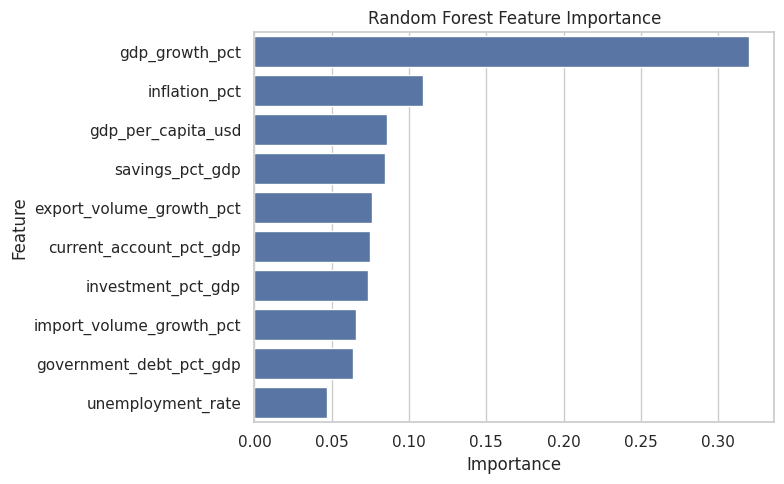

In [43]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": forest_model.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x="importance", y="feature")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weo_ml_feature_importance.png", dpi=150)
plt.show()

### Interpreting Feature Importance

The current output ranks **current-year GDP growth** highest, followed by **inflation**, **GDP per capita**, **savings**, and **export growth**. This is reasonable because recent growth often carries information about near-term growth, but it should not be interpreted as proof that these variables cause future GDP growth.

## 15. Export the Best Model and Test One Country

This cell saves the best model by MAE and uses it to predict next-year GDP growth for Lesotho from the latest available WEO feature row.

In [44]:
model_path = OUTPUT_DIR / "weo_next_year_gdp_growth_model.joblib"
dump(best_model, model_path)

loaded_model = load(model_path)
lesotho_rows = model_df[model_df["country"].eq("Lesotho, Kingdom of")].sort_values("year")
latest_lesotho = lesotho_rows.dropna(subset=["gdp_growth_pct"]).tail(1)

if latest_lesotho.empty:
    print("Lesotho was not available in the prepared model data.")
else:
    lesotho_features = latest_lesotho[feature_columns]
    lesotho_prediction = loaded_model.predict(lesotho_features)[0]
    display(latest_lesotho[["country", "year"] + feature_columns])
    print("Best model by MAE:", best_model_name)
    print("Predicted next-year GDP growth for Lesotho:", round(lesotho_prediction, 2), "%")
    print("Saved model:", model_path)

,country,year,gdp_growth_pct,inflation_pct,unemployment_rate,government_debt_pct_gdp,current_account_pct_gdp,investment_pct_gdp,savings_pct_gdp,export_volume_growth_pct,import_volume_growth_pct,gdp_per_capita_usd
5121,"Lesotho, Kingdom of",2031,1.512,4.0,NaN,50.01,-0.053,38.08,38.027,2.275,2.661,1472.003


Best model by MAE: linear_regression
Predicted next-year GDP growth for Lesotho: 3.45 %
Saved model: outputs/weo_next_year_gdp_growth_model.joblib


## 16. Export Model Outputs

In [45]:
metrics_path = OUTPUT_DIR / "weo_ml_model_metrics.csv"
predictions_path = OUTPUT_DIR / "weo_ml_prediction_review.csv"
importance_path = OUTPUT_DIR / "weo_ml_feature_importance.csv"

metrics.to_csv(metrics_path, index=False)
prediction_review.round(4).to_csv(predictions_path, index=False)
feature_importance.to_csv(importance_path, index=False)

print("Saved:", metrics_path)
print("Saved:", predictions_path)
print("Saved:", importance_path)

Saved: outputs/weo_ml_model_metrics.csv
Saved: outputs/weo_ml_prediction_review.csv
Saved: outputs/weo_ml_feature_importance.csv
